In [1]:
%cd /u/jcai1/code/usefulxai/code/my_method

import openslide
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
from modules.mhim import MHIM
import cv2
import random
import seaborn as sns
import os

/scratch/bdem/jcai1/bdem_usefulxai/code/my_method


## 第一步：读取特征和 patch 坐标（来自 .h5）

In [20]:
# 第一步：读取特征和 patch 坐标（来自 .h5）
import h5py
import torch

def load_features_and_coords(h5_path):
    with h5py.File(h5_path, 'r') as f:
        features = torch.from_numpy(f['features'][:])  # shape: [N, D]
        coords = f['coords'][:]  # shape: [N, 2], each is [x, y]
    print(f"Loaded {features.shape[0]} patches, feature dim: {features.shape[1]}, coords shape: {coords.shape}")
    return features, coords

features, coords = load_features_and_coords("/u/jcai1/code/usefulxai/data/camelyon16-clam/tumor_vs_normal_resnet_features/h5_files_labels/normal_001.h5")
x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
y_min, y_max = coords[:, 1].min(), coords[:, 1].max()

print(f"X range: {x_min} → {x_max}")
print(f"Y range: {y_min} → {y_max}")

Loaded 7974 patches, feature dim: 1024, coords shape: (7974, 2)
X range: 30592 → 74880
Y range: 86144 → 127872


## 第二步：读取已训练好模型的attention score

In [ ]:
# Attention for TransMIL
pure = MHIM(da_act='relu',baseline='selfattn').eval()
pure.requires_grad_(False)

pure_cpt = torch.load('/u/jcai1/code/usefulxai/paper_results/transmil_0507_1818/fold_0_model_best_auc.pt',map_location='cpu')

pure.load_state_dict(pure_cpt['model'], strict=False)
pure.eval()
with torch.no_grad():
    _, attns = pure.forward_test(features.unsqueeze(0),return_attn=True)
    attn = attns[-1].mean(dim=1).squeeze(0) # Take last layer
    print(attn.shape)
attn_scores = attn.cpu().numpy()
print(attn_scores)


## 第三步：根据mask文件得到绘制区间（level0）

In [ ]:
from openslide import OpenSlide
import numpy as np

def get_tumor_region_from_mask(mask_path, mask_level=8):
    mask_slide = OpenSlide(mask_path)
    print("Level dimensions of mask:", mask_slide.level_dimensions)
    dims = mask_slide.level_dimensions[mask_level]
    mask_img = mask_slide.read_region((0, 0), mask_level, dims).convert("L")
    mask_arr = np.array(mask_img)
    
    mask_h, mask_w = mask_arr.shape
    x_range = (0, mask_w - 1)
    y_range = (0, mask_h - 1)
    print(f"Full X range of mask (level 8): {x_range}")
    print(f"Full Y range of mask (level 8): {y_range}")

    coords = np.argwhere(mask_arr == 2)
    if len(coords) == 0:
        print("No tumor (label==2) found in entire mask!")
        return None
    
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    print(f"Tumor region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested tumor region (level 0):", region)
    
    coords = np.argwhere(mask_arr == 1)
    if len(coords) == 0:
        print("No normal (label==1) found in entire mask!")
        return None
    
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    print(f"Normal region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested normal region (level 0):", region)
    
get_tumor_region_from_mask("/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif")

Level dimensions of mask: ((97792, 221184), (48896, 110592), (24448, 55296), (12224, 27648), (6112, 13824), (3056, 6912), (1528, 3456), (764, 1728), (382, 864))
Full X range of mask (level 8): (0, 381)
Full Y range of mask (level 8): (0, 863)
Tumor region in mask level 8: x=[274, 286], y=[479, 525]
Suggested tumor region (level 0): (70144, 122624, 73216, 134400)
Normal region in mask level 8: x=[3, 351], y=[57, 826]
Suggested normal region (level 0): (768, 14592, 89856, 211456)


## 第四步：在原图上绘制attention和groud-truth annotation轮廓

[INFO] Reading image region at level 0
        Region coordinates (level 0): left=70144, top=122624, width=3072, height=11776
[INFO] Image region loaded. Shape: (11776, 3072, 3)
[INFO] Reading mask region at level 8: origin=(70144, 122624), size=(12, 46)
[INFO] Partial mask shape: (11776, 3072), unique labels: [0 1 2]
  tumor_mask shape: (11776, 3072)
  heatmap shape   : (11776, 3072, 3)
[INFO] Found 2 contours
[INFO] Attn min: 0.0 max: 0.9951259


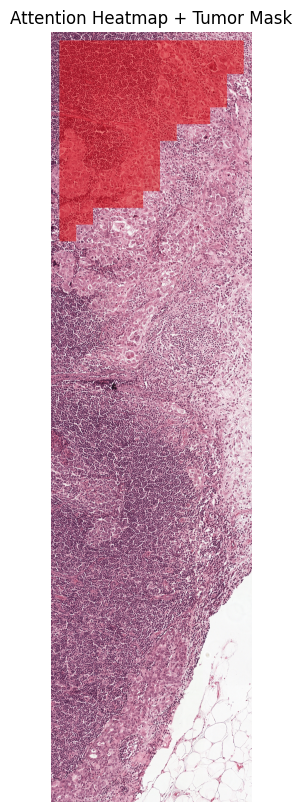

In [25]:
import openslide
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_attention_on_region(svs_path, coords, attn_scores, 
                             patch_size=256, level=0, alpha=0.5,
                             region=None,
                             mask_path=None, mask_level=8):  # <<< 新增参数
    # * -------------- 读取原图片对应region部分（level0） --------------
    slide = openslide.OpenSlide(svs_path)
    downsample = slide.level_downsamples[level] # 1.0
    
    if region is None:
        left, top = 0, 0
        right, bottom = slide.level_dimensions[level]
    else:
        left, top, right, bottom = region

    w, h = right - left, bottom - top
    base_img = np.array(slide.read_region((left, top), level, (w, h)).convert("RGB"))
    heatmap = base_img.copy()
    print(f"[INFO] Reading image region at level {level}")
    print(f"        Region coordinates (level 0): left={left}, top={top}, width={w}, height={h}")
    print(f"[INFO] Image region loaded. Shape: {heatmap.shape}")

    # * -------------- 加载mask并绘制轮廓 --------------
    if mask_path is not None:
        mask_slide = openslide.OpenSlide(mask_path)
        mask_downsample = mask_slide.level_downsamples[mask_level]
        width, height = mask_slide.level_dimensions[mask_level]

        # 将 region 从 level 0 映射到 mask_level=8（用于读取子图）
        left_mask = int(left / mask_downsample)
        top_mask = int(top / mask_downsample)
        w_mask = int(w / mask_downsample)
        h_mask = int(h / mask_downsample)
        
        # 读取完整 mask（level=mask_level），用于调试或边界提取
        # full_mask_img = mask_slide.read_region((0, 0), mask_level, mask_slide.level_dimensions[mask_level]).convert("L")
        # full_mask_arr = np.array(full_mask_img)
        # tumor_mask_full = (full_mask_arr == 2).astype(np.uint8)
        # tumor_coords = np.argwhere(tumor_mask_full == 1)
        # print("[INFO] Loaded full mask")
        # print(f"        Unique labels in mask: {np.unique(full_mask_arr)}")
        # print(f"        Tumor pixel count (label==2): {np.sum(tumor_mask_full)}")
        # if tumor_coords.size > 0:
        #     y_min, x_min = tumor_coords.min(axis=0)
        #     y_max, x_max = tumor_coords.max(axis=0)
        #     print(f"        Tumor bounding box (mask_level): x={x_min}~{x_max}, y={y_min}~{y_max}")
        # else:
        #     print("        No tumor region found in full mask.")
                
        # 读取指定区域的局部 mask（坐标必须是 level 0 下的）
        print(f"[INFO] Reading mask region at level {mask_level}: origin=({left}, {top}), size=({w_mask}, {h_mask})")
        # mask_img = mask_slide.read_region((left, top), mask_level, (w_mask, h_mask)).convert("L")
        mask_img = mask_slide.read_region((left, top), 0, (w, h)).convert("L")
        mask_arr = np.array(mask_img)
        
        print(f"[INFO] Partial mask shape: {mask_arr.shape}, unique labels: {np.unique(mask_arr)}")
        
        # 提取 tumor 区域并绘制边界（仅 label==2）
        tumor_mask = (mask_arr == 2).astype(np.uint8)
        
        # Important! 确保tumor_mask和heatmap对的上！！！
        print(f"  tumor_mask shape: {tumor_mask.shape}")
        print(f"  heatmap shape   : {heatmap.shape}")
        
        
        contours, _ = cv2.findContours(tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        print(f"[INFO] Found {len(contours)} contours")
        
        # 将轮廓绘制到heatmap（黑色）
        cv2.drawContours(heatmap, contours, -1, (0, 0, 0), 2)
        

    # ------------------------------------------------

    # normalize attention
    attn_norm = (attn_scores - attn_scores.min()) / (attn_scores.max() - attn_scores.min() + 1e-6)
    print("[INFO] Attn min:", attn_norm.min(), "max:", attn_norm.max())
    
    for i, (x, y) in enumerate(coords):
        x_lv = x / downsample
        y_lv = y / downsample
        if region and not (left <= x_lv < right and top <= y_lv < bottom):
            continue  # skip patches outside region
        
        rel_x = int(x_lv - left)
        rel_y = int(y_lv - top)
        patch_w = patch_h = max(int(patch_size / downsample), 1)
        color = plt.cm.jet(attn_norm[i])[:3]
        color = tuple(int(255 * c) for c in color)
        cv2.rectangle(heatmap, (rel_x, rel_y), (rel_x + patch_w, rel_y + patch_h), color, -1) # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图。

    blended = cv2.addWeighted(heatmap, alpha, base_img, 1 - alpha, 0)

    # show image
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis("off")
    plt.title("Attention Heatmap + Tumor Mask")
    plt.show()
    
# region = (70144, 122624, 73472, 134656)  # 在 level=0 下的 region
region = (70144, 122624, 73216, 134400)
show_attention_on_region(
    svs_path="/u/jcai1/code/usefulxai/data/camelyon16/images/tumor_001.tif",
    coords=coords,
    attn_scores=attn_scores,
    region=region,
    mask_path="/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif"
)
